# WCTE - Ni-Cf source calibration
# FromKaMing_forClaudeReco_noCuts Data

## Tareas para 17/04/2026

- Aplicar los cortes q hice por separado pero todo junto ahora (el corte d la carga no hace falta) a los datos nuevos de diego!!

- Hacer la resta bin a bin bien (para que sig no esté desplazada); esto pensarlo bien de bien

- En la distribución tRMS investigar la colina después del pico. Aquí hacer varios histogramas (como 20 o 50) así: antes un histograma de nº de hits en cada evento, ahora cogemos un evento y hacemos el hist de tRMS de cada hit en su evento. Vemos si hay algún patrón de hits en el mismo evento. Diego y JA sospechan que es por carga que salta sistemáticamente en la electrónica del PMT.

- Ahora esto tengo que pensarlo bn: tengo que calcular el vértice de reconstrucción $\vec{x}$ usando los tiempos. Tengo que buscar la posición $x$ que hace que los tiempos medidos y los predichos coincidan lo mejor posible. Osea, distintas posiciones del evento hasta encintrar la que mejor explica los tiempos observados. Tengo que minimizar esta cantidad, por mínimos cuadrados quizás? Básicamente tengo que hacer un fit

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

pltext.style()

## Datos

In [2]:
datapath = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/"    #ahora los csv están en mi carpeta
filename_bkg = "df_bkgFromKaMing_forClaudeReco_noCuts.csv" 
data_bkg     = pd.read_csv(datapath+filename_bkg)

filename_sig = "df_sigFromKaMing_forClaudeReco_noCuts.csv"
data_sig     = pd.read_csv(datapath+filename_sig)


In [3]:
data_bkg

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,209221.084343,103.0,19,12,373
1,1,0,0,209223.152791,119.0,19,4,365
2,2,0,0,209233.144440,175.0,19,10,371
3,3,0,1,209588.321986,97.0,100,0,1900
4,4,0,1,209590.743413,104.0,101,13,1932
...,...,...,...,...,...,...,...,...
18253236,18253236,83110,645853,247287.565400,180.0,3,18,75
18253237,18253237,83110,645854,331560.611688,141.0,8,1,153
18253238,18253238,83110,645854,331562.449078,97.0,2,1,39
18253239,18253239,83110,645854,331566.346411,132.0,52,10,998


In [4]:
data_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,63479.663380,83.0,1,5,24
1,1,0,0,63480.392541,133.0,46,12,886
2,2,0,0,63496.106182,180.0,8,5,157
3,3,0,1,65913.196181,75.0,69,17,1328
4,4,0,1,65913.202297,137.0,70,1,1331
...,...,...,...,...,...,...,...,...
30143260,30143260,83111,1955360,494925.804957,111.0,88,9,1681
30143261,30143261,83111,1955360,494926.207864,215.0,90,16,1726
30143262,30143262,83111,1955360,494926.448105,161.0,88,8,1680
30143263,30143263,83111,1955360,494926.550472,61.0,89,17,1708


El proceso es el siguiente:

$^{252}\text{Cf}\rightarrow ^{148}\text{Ba}+^{106}\text{Mo}+4n$

$^{58}\text{Ni}+n\rightarrow ^{59}\text{Ni}+\gamma$

Los fotones son los que se detectan, vemos que en este run detectamos 1433056 fotones (hits) de background. Para organizar esta gigantesca información definimos los "eventos", que corresponden a la toma de datos en un intervalo de tiempo de 500 [microsegundos], cada uno con un número variable de fotones que llegan al WCTE. Indexamos los eventos con el event_id. En estos eventos debemos separar el "ruido" de los candidates (fotones registrados que provienen del decay del $^{58}\text{Ni}$).

Como me interesan los eventos agrupo los hits en su evento correspondiente con .groupby(). Sumo hit_pmt_charges (carga total en cada evento), cuento cuántos hits tiene cada evento (cuántos fotones tiene cada evento), y la RMS del tiempo (si trms es pequeña los hits han llegado casi al mismo tiempo al PMT en este evento).

In [5]:
data_by_event_bkg=data_bkg.groupby("event_id")

total_charge_by_event_bkg = data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size() #.size() devuelve el nº de elementos, osea el nº de hits en cada evento
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std() #.std() ya lo calcula q facil, pero por q se le llama total_trms?? No hay solo una?

print(f"Tenemos {len(data_by_event_bkg)} eventos (grupos de hits) de bkg") #este será nuestro eje x en los scatters

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()

print(f"Tenemos {len(data_by_event_sig)} eventos (grupos de hits) de sig+bkg") #este será nuestro eje x en los scatters

Tenemos 82793 eventos (grupos de hits) de bkg
Tenemos 83104 eventos (grupos de hits) de sig+bkg


## Muestras contaminadas

Hemos almacenado la carga total por evento, el nº de hits por evento y la trms por evento en series: total_charge_by_event_bkg, total_nhits_by_event_bkg, total_trms_by_event_bkg (igual para los datos de señal). Ahora hacemos un gráfico de dispersión (scatter plot, no une los puntos) de cada serie frente el índice que indexa cada evento.

plt.scatter(x.index, y.values) ; .index indexa los elementos de la serie y coge los índices, .values da los valores

Text(0.5, 0.92, 'Muestras iniciales (contaminadas). Con 82793 eventos de bkg y 83104 eventos de sig+bkg')

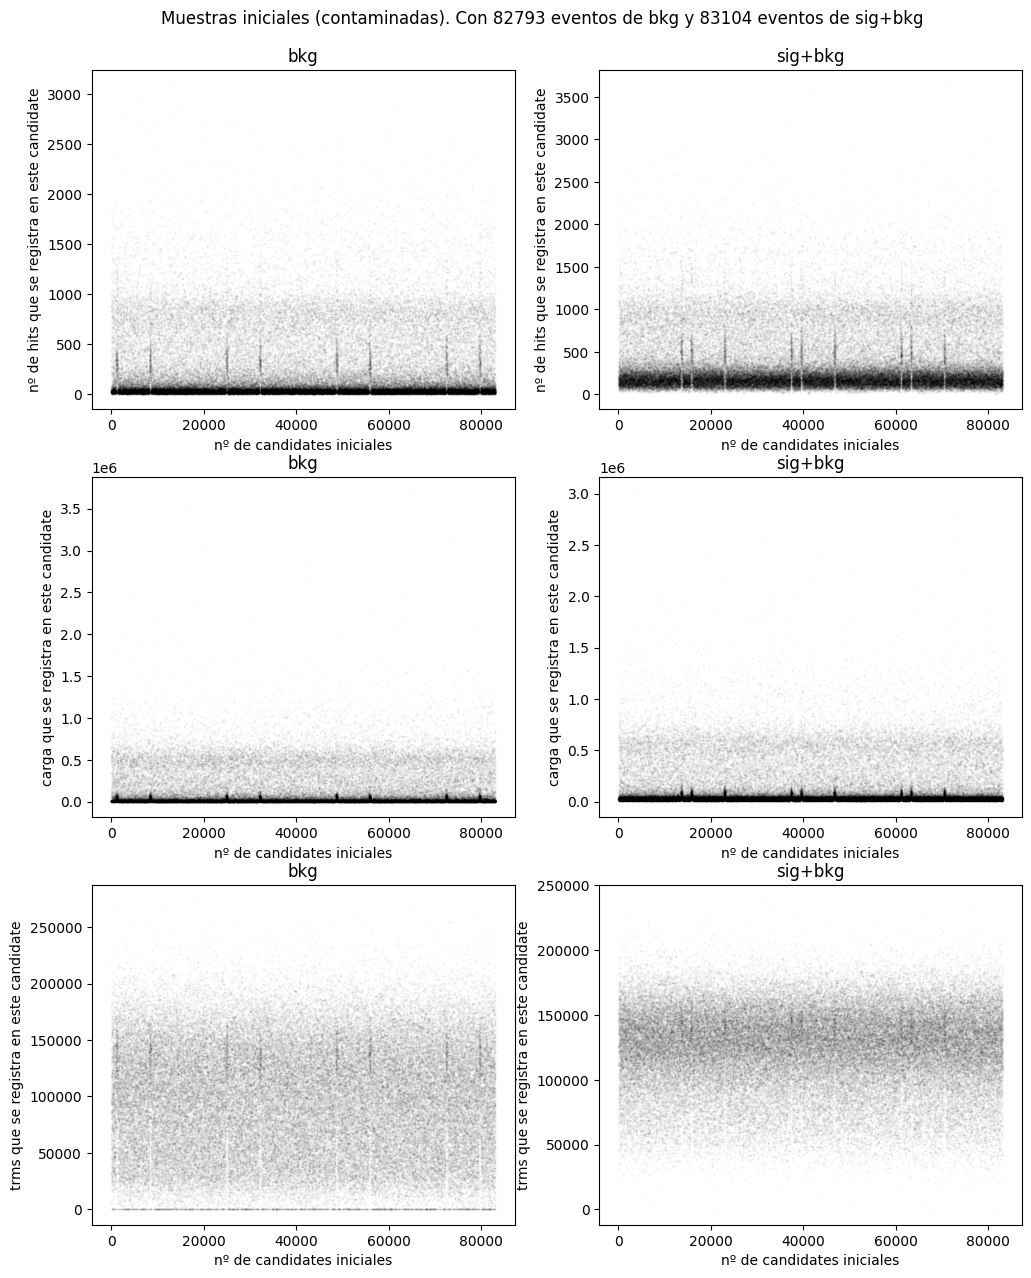

In [6]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

subplot(3)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("carga que se registra en este candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("carga que se registra en este candidate")
plt.title("sig+bkg")

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("trms que se registra en este candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("trms que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle(f"Muestras iniciales (contaminadas). Con {len(data_by_event_bkg)} eventos de bkg y {len(data_by_event_sig)} eventos de sig+bkg", y=0.92)

#plt.savefig(f"{output_directory}/Muestras_contaminadas.png", dpi=500, bbox_inches="tight")

## Muestras de candidates descontaminadas

Utilizaremos el scatter "nº total de hits de cada candidate vs nº de candidate" para eliminar los eventos que no nos interesan y quedarnos con los candidates buenos. Hago de nuevo este scatter:

Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

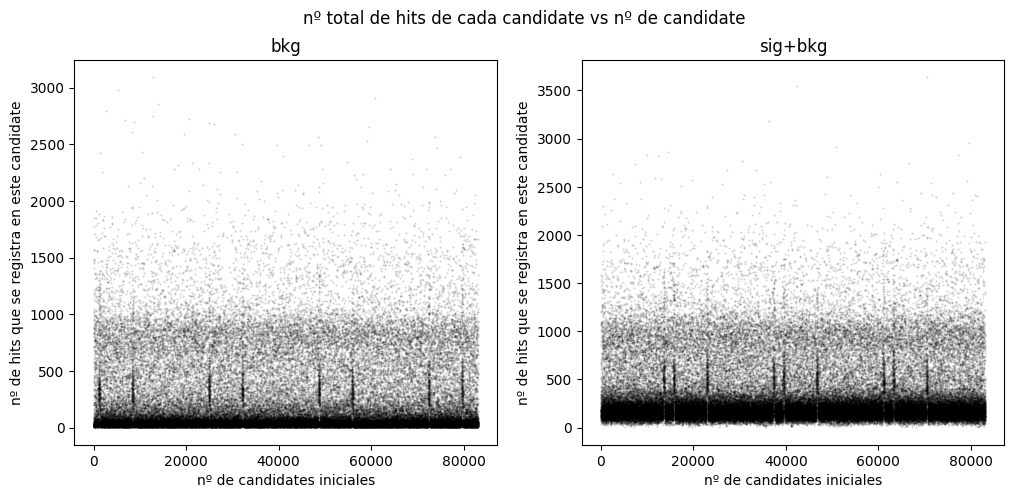

In [7]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

Vemos que es evidente que los spills tienen una periodicidad, esto podría inspeccionarlo más a fondo pero de momento voy solo a quitarlos. Aquí no hay valores saturantes. Además, en bkg se miden muchos eventos que registran entre 500-1000 hits, esto tiene que ser ruido de una fuente externa porque es imposible que sea señal.

In [8]:
#quiero quitar los spills y los que saturan

#lo lógico primero es bucar cuál es el valor exacto de saturación:
max_value_of_total_nhits_by_event_bkg = total_nhits_by_event_bkg.max()  #aquí .max() va con () porque realiza un cálculo

print(f"{max_value_of_total_nhits_by_event_bkg} es el valor al que satura el nº de hits en los candidates para bkg")

#vemos con el valor máximo y cambiando el alpha que no hay valores saturantes

#igual para signal
max_value_of_total_nhits_by_event_sig = total_nhits_by_event_sig.max()
print(f"{max_value_of_total_nhits_by_event_sig} es el valor al que satura el nº de hits en los candidates para sig+bkg")

3091 es el valor al que satura el nº de hits en los candidates para bkg
3637 es el valor al que satura el nº de hits en los candidates para sig+bkg


(71500.0, 81500.0)

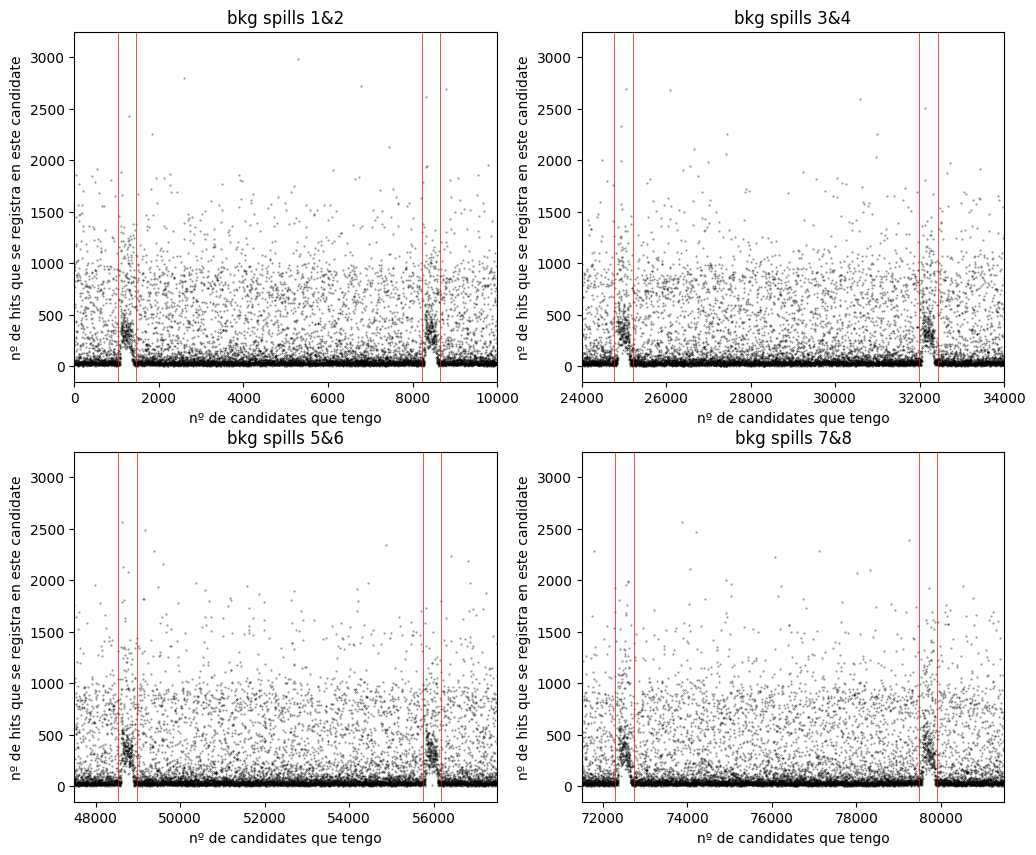

In [9]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(4)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 1&2")

x_lines_spill1_bkg = [1020, 1450]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill2_bkg = [8215, 8645]      #configuro el intervalo igual para los dos: 430
for x in x_lines_spill1_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0, 10000)
#plt.ylim(0,140)

subplot(2)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 3&4")

x_lines_spill3_bkg = [24775, 25205]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill4_bkg = [31990, 32420]
for x in x_lines_spill3_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill4_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(24000, 34000)
#plt.ylim(0,140)

subplot(3)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 5&6")

x_lines_spill5_bkg = [48540, 48970]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill6_bkg = [55740, 56170]
for x in x_lines_spill5_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill6_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(47500, 57500)
#plt.ylim(0,140)

subplot(4)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spills 7&8")

x_lines_spill7_bkg = [72300, 72730]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill8_bkg = [79475, 79905]
for x in x_lines_spill7_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(71500, 81500)
#plt.ylim(0,140)


(60000.0, 71300.0)

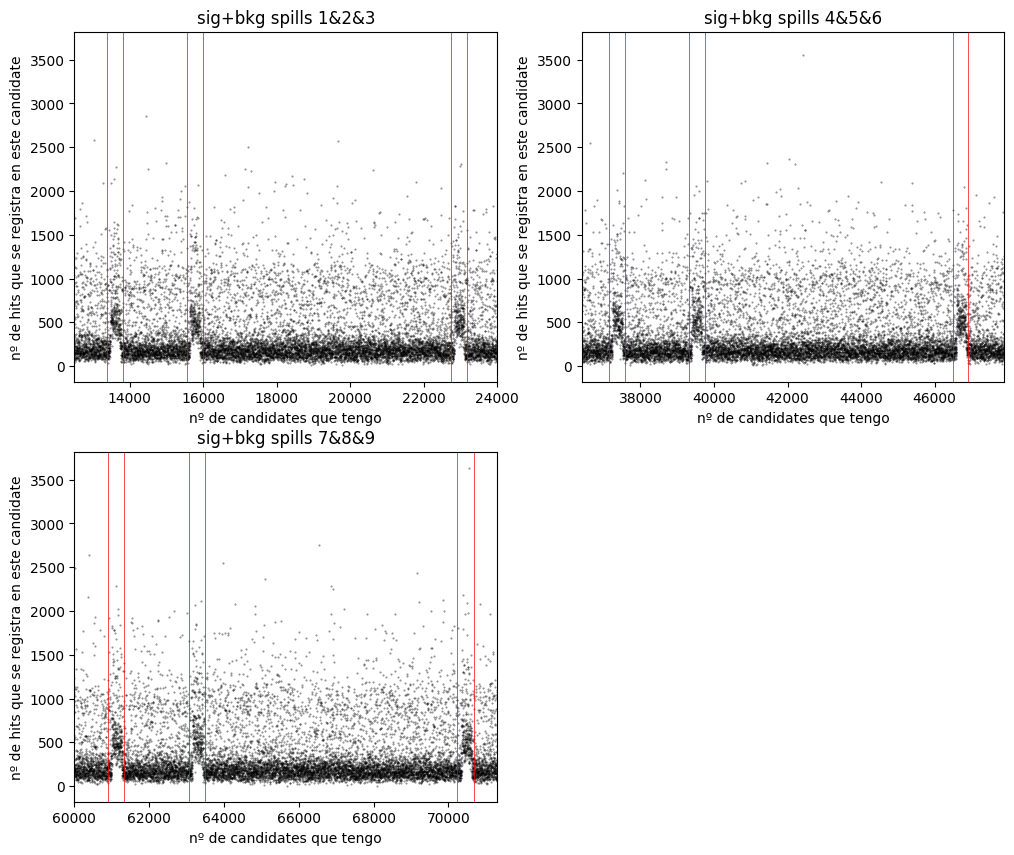

In [10]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(3)

subplot(1)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 1&2&3")

x_lines_spill1_sig = [13400, 13830]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill2_sig = [15570, 16000]      #configuro el intervalo igual para los dos: 430
x_lines_spill3_sig = [22740, 23170]
for x in x_lines_spill1_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill3_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(12500, 24000)
#plt.ylim(0,140)

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 4&5&6")

x_lines_spill4_sig = [37150, 37580]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill5_sig = [39320, 39750]      #configuro el intervalo igual para los dos: 430
x_lines_spill6_sig = [46490, 46920]
for x in x_lines_spill4_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill5_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill6_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(36400, 47900)
#plt.ylim(0,140)

subplot(3)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spills 7&8&9")

x_lines_spill7_sig = [60900, 61330]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill8_sig = [63070, 63500]      #configuro el intervalo igual para los dos: 430
x_lines_spill9_sig = [70240, 70670]
for x in x_lines_spill7_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill9_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(60000, 71300)
#plt.ylim(0,140)


In [11]:
x_min_s1_bkg = 1020; x_max_s1_bkg = 1450
x_min_s2_bkg = 8215; x_max_s2_bkg = 8645
x_min_s3_bkg = 24775; x_max_s3_bkg = 25205
x_min_s4_bkg = 31990; x_max_s4_bkg = 32420
x_min_s5_bkg = 48540; x_max_s5_bkg = 48970
x_min_s6_bkg = 55740; x_max_s6_bkg = 56170
x_min_s7_bkg = 72300; x_max_s7_bkg = 72730
x_min_s8_bkg = 79475; x_max_s8_bkg = 79905

x_min_s1_sig = 13400; x_max_s1_sig = 13830
x_min_s2_sig = 15570; x_max_s2_sig = 16000
x_min_s3_sig = 22740; x_max_s3_sig = 23170
x_min_s4_sig = 37150; x_max_s4_sig = 37580
x_min_s5_sig = 39320; x_max_s5_sig = 39750
x_min_s6_sig = 46490; x_max_s6_sig = 46920
x_min_s7_sig = 60900; x_max_s7_sig = 61330
x_min_s8_sig = 63070; x_max_s8_sig = 63500
x_min_s9_sig = 70240; x_max_s9_sig = 70670


#series que hay que quitar
spill_1_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s1_bkg) & (total_nhits_by_event_bkg.index <= x_max_s1_bkg)]
spill_2_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s2_bkg) & (total_nhits_by_event_bkg.index <= x_max_s2_bkg)]
spill_3_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s3_bkg) & (total_nhits_by_event_bkg.index <= x_max_s3_bkg)]
spill_4_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s4_bkg) & (total_nhits_by_event_bkg.index <= x_max_s4_bkg)]
spill_5_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s5_bkg) & (total_nhits_by_event_bkg.index <= x_max_s5_bkg)]
spill_6_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s6_bkg) & (total_nhits_by_event_bkg.index <= x_max_s6_bkg)]
spill_7_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s7_bkg) & (total_nhits_by_event_bkg.index <= x_max_s7_bkg)]
spill_8_bkg = total_nhits_by_event_bkg[(total_nhits_by_event_bkg.index >= x_min_s8_bkg) & (total_nhits_by_event_bkg.index <= x_max_s8_bkg)]

spill_1_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s1_sig) & (total_nhits_by_event_sig.index <= x_max_s1_sig)]
spill_2_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s2_sig) & (total_nhits_by_event_sig.index <= x_max_s2_sig)]
spill_3_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s3_sig) & (total_nhits_by_event_sig.index <= x_max_s3_sig)]
spill_4_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s4_sig) & (total_nhits_by_event_sig.index <= x_max_s4_sig)]
spill_5_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s5_sig) & (total_nhits_by_event_sig.index <= x_max_s5_sig)]
spill_6_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s6_sig) & (total_nhits_by_event_sig.index <= x_max_s6_sig)]
spill_7_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s7_sig) & (total_nhits_by_event_sig.index <= x_max_s7_sig)]
spill_8_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s8_sig) & (total_nhits_by_event_sig.index <= x_max_s8_sig)]
spill_9_sig = total_nhits_by_event_sig[(total_nhits_by_event_sig.index >= x_min_s9_sig) & (total_nhits_by_event_sig.index <= x_max_s9_sig)]

#hay que concatenar sus índices, NO SUMAR.
combined_series_bkg = pd.concat([spill_1_bkg, spill_2_bkg, spill_3_bkg, spill_4_bkg, spill_5_bkg, spill_6_bkg, spill_7_bkg, spill_8_bkg]) 
combined_series_sig = pd.concat([spill_1_sig, spill_2_sig, spill_3_sig, spill_4_sig, spill_5_sig, spill_6_sig, spill_7_sig, spill_8_sig, spill_9_sig])

total_nhits_by_event_bkg_clean = total_nhits_by_event_bkg.drop(combined_series_bkg.index)
total_charge_by_event_bkg_clean = total_charge_by_event_bkg.loc[total_nhits_by_event_bkg_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_event_bkg_clean = total_trms_by_event_bkg.loc[total_nhits_by_event_bkg_clean.index]


total_nhits_by_event_sig_clean = total_nhits_by_event_sig.drop(combined_series_sig.index)
total_charge_by_event_sig_clean = total_charge_by_event_sig.loc[total_nhits_by_event_sig_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_event_sig_clean = total_trms_by_event_sig.loc[total_nhits_by_event_sig_clean.index]


###

print(f"Hemos juntado en una pd.Series con {len(combined_series_bkg)} eventos los 8 spills de bkg, que representa el {len(combined_series_bkg)/len(total_nhits_by_event_bkg)*100:.4f}% de la muestra inicial de bkg")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_event_bkg)-len(combined_series_bkg)} eventos que representan el {(len(total_nhits_by_event_bkg)-len(combined_series_bkg))/len(total_nhits_by_event_bkg)*100:.4f}% de la muestra inicial de bkg")
print(f"En total, hemos quitado {len(total_nhits_by_event_bkg)-len(total_charge_by_event_bkg_clean)} eventos de bkg")

print("\n")

print(f"Para sig+bkg tenemos {len(combined_series_sig)} eventos los 9 spills que hay en sig+bkg, que representa el {len(combined_series_sig)/len(total_nhits_by_event_sig)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_event_sig)-len(combined_series_sig)} eventos que representan el {(len(total_nhits_by_event_sig)-len(combined_series_sig))/len(total_nhits_by_event_sig)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"En total, hemos quitado {len(total_nhits_by_event_sig)-len(total_charge_by_event_sig_clean)} eventos de sig+bkg")


Hemos juntado en una pd.Series con 3444 eventos los 8 spills de bkg, que representa el 4.1598% de la muestra inicial de bkg
Nos queda la pd.Series descontaminada (clean), con 79349 eventos que representan el 95.8402% de la muestra inicial de bkg
En total, hemos quitado 3444 eventos de bkg


Para sig+bkg tenemos 3879 eventos los 9 spills que hay en sig+bkg, que representa el 4.6676% de la muestra inicial de sig+bkg
Nos queda la pd.Series descontaminada (clean), con 79225 eventos que representan el 95.3324% de la muestra inicial de sig+bkg
En total, hemos quitado 3879 eventos de sig+bkg


Text(0.5, 0.92, 'Muestras descontaminadas. Con 79349 eventos de bkg y 79225 eventos de sig+bkg')

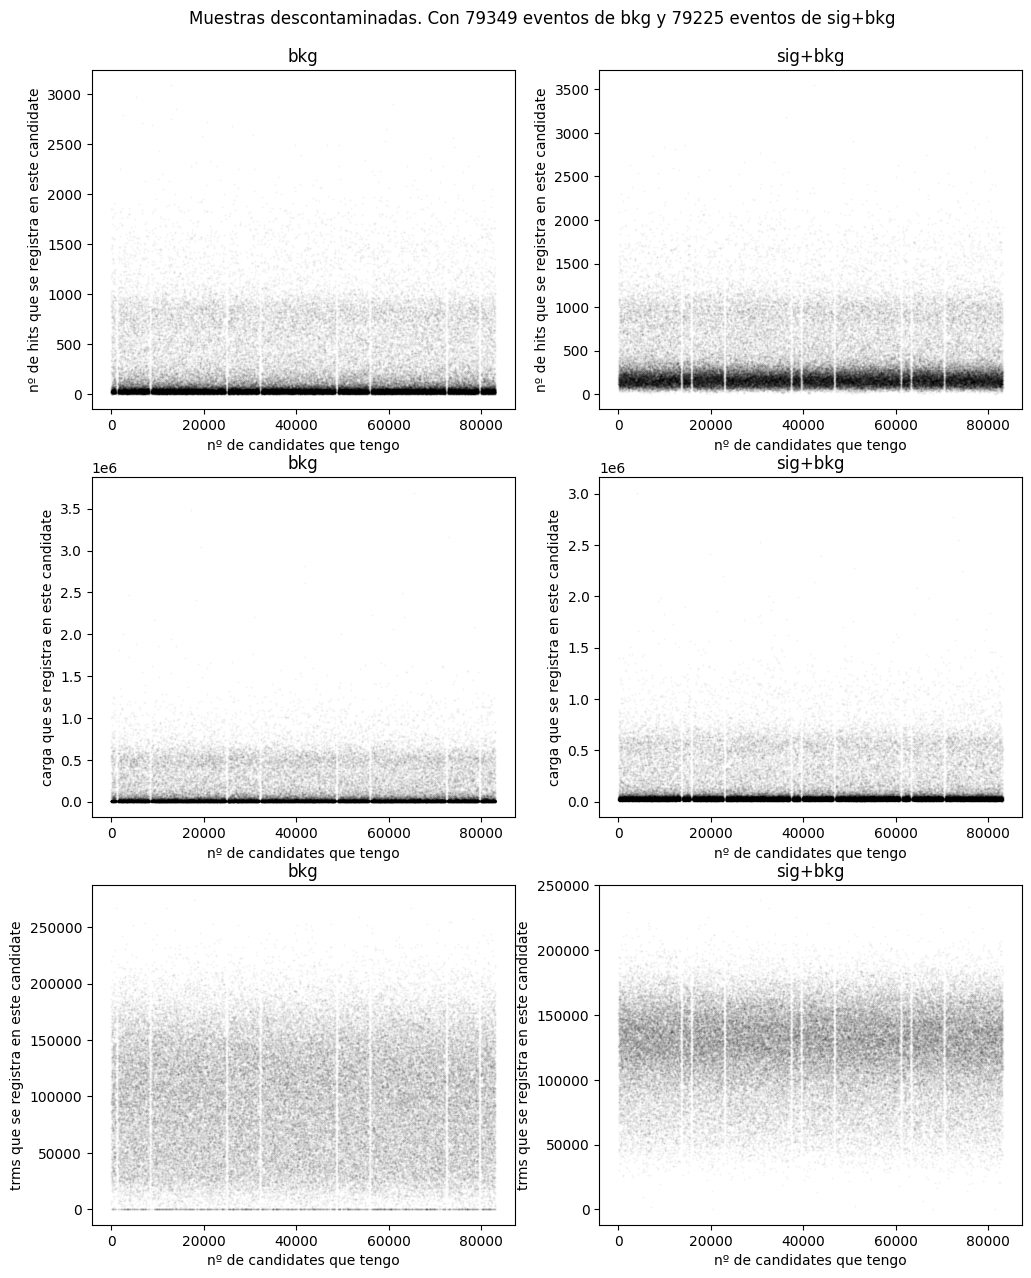

In [12]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_event_bkg_clean.index, total_nhits_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_event_sig_clean.index, total_nhits_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")    #NO SE LLAMABAN CANDIDATES
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")


subplot(3)
plt.scatter(total_charge_by_event_bkg_clean.index, total_charge_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_event_sig_clean.index, total_charge_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("sig+bkg")


subplot(5)
plt.scatter(total_trms_by_event_bkg_clean.index, total_trms_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_event_sig_clean.index, total_trms_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle(f"Muestras descontaminadas. Con {len(total_nhits_by_event_bkg)-len(combined_series_bkg)} eventos de bkg y {len(total_nhits_by_event_sig)-len(combined_series_sig)} eventos de sig+bkg", y=0.92)

#plt.savefig(f"{output_directory}/Muestras_descontaminadas.png", dpi=500, bbox_inches="tight")

## Distribución de hits por evento

Text(0.5, 0.98, 'Distribución de hits por evento')

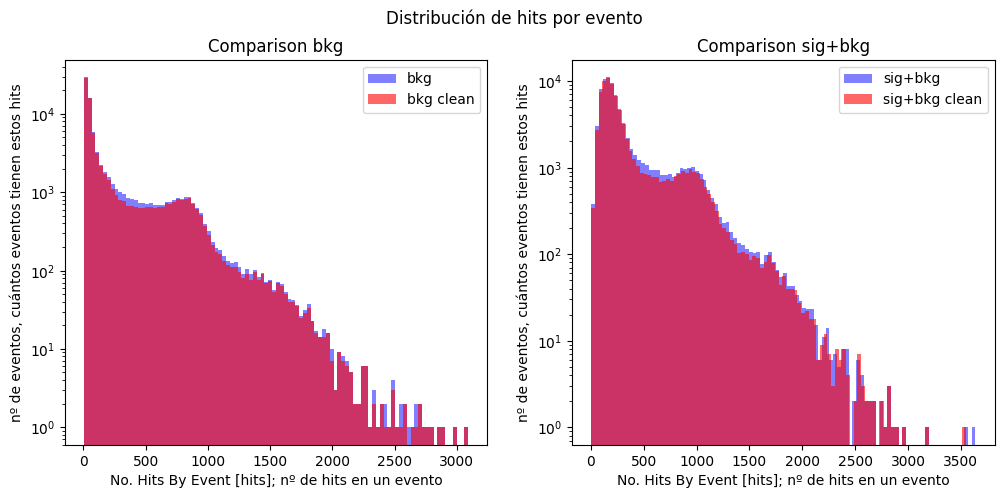

In [13]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_nhits_by_event_bkg, 100, histtype="stepfilled", label="bkg", alpha=0.5, color="b")   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_event_bkg_clean, 100, histtype="stepfilled", label="bkg clean", alpha=0.6, color="r")
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Comparison bkg")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_nhits_by_event_sig, 100, histtype="stepfilled", label="sig+bkg", alpha=0.5, color="b")
plt.hist(total_nhits_by_event_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", alpha=0.6, color="r")
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Comparison sig+bkg")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de hits por evento")

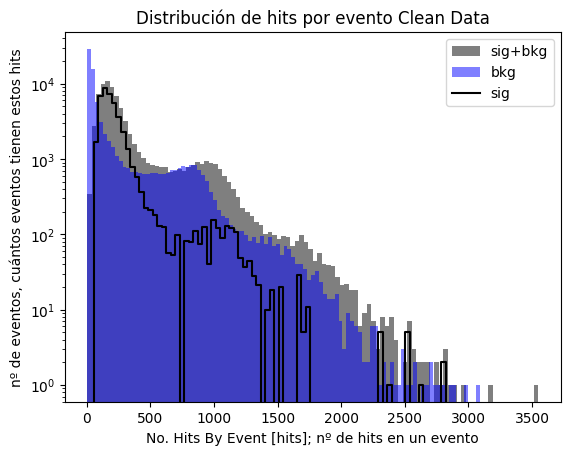

In [14]:
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, label="sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
#plt.yscale('linear') #para ver que no es que sig empiece desplazada, sino que es negativa
plt.legend()



## Distribución de carga total por evento

Text(0.5, 0.98, 'Distribución de carga total por evento')

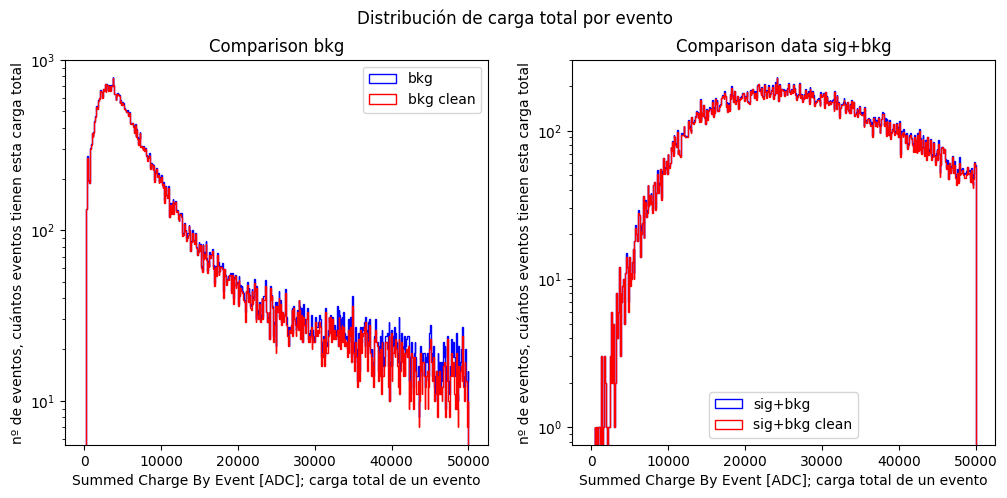

In [15]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_charge_by_event_bkg, 500, histtype="step", label="bkg", range=(0, 50e3), color="b")   #500 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_event_bkg_clean, 500, histtype="step", label="bkg clean", range=(0, 50e3), color="r")
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Comparison bkg")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_charge_by_event_sig, 500, histtype="step", label="sig+bkg", range=(0, 50e3), color="b")   #500 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_event_sig_clean, 500, histtype="step", label="sig+bkg clean", range=(0, 50e3), color="r")
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Comparison data sig+bkg")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de carga total por evento")

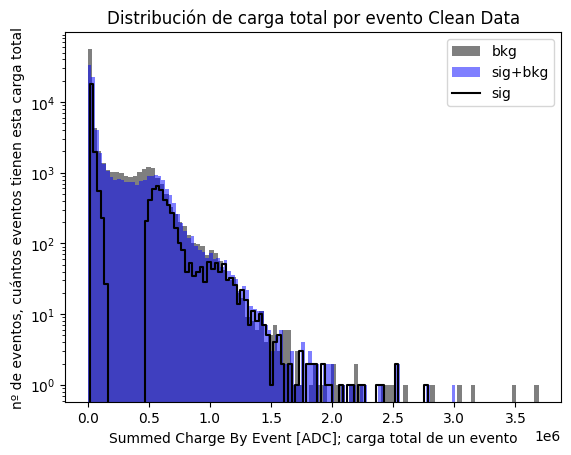

In [16]:
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
#para ver mejor range=(0,2000)

bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin

#total_charge_by_event_only_sig = pd.Series(counts_sig_charge - counts_bkg_charge, index=bin_centers_charge) #creo la pd.Series de la señal limpia (sólo la señal)
#plt.hist(counts_sig_charge - counts_bkg_charge, 100, histtype = "stepfilled" ,alpha=1, label="sig") # ESTÁ MAL???

plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, label="sig", color="k")


#esto es lo que hice yo, está mal
weights_sig_charge = np.ones_like(total_charge_by_event_sig_clean)
weights_bkg_charge_4 = -  1*np.ones_like(total_charge_by_event_bkg_clean)   #asumimos normaliz bkg = sig+bkg perfecto
all_charge = np.concatenate([total_charge_by_event_sig_clean, total_charge_by_event_bkg_clean])   #lo junto todo
all_weights_charge_4 = np.concatenate([weights_sig_charge, weights_bkg_charge_4])
#plt.hist(all_charge, 100, weights=all_weights_charge_4, histtype="step", color="r", alpha=1, label="sig4, not correct")

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
#plt.xlim(0,20000)
plt.legend()

## Distribución de tRMS por evento

Text(0.5, 0.98, 'Distribución de tRMS por evento')

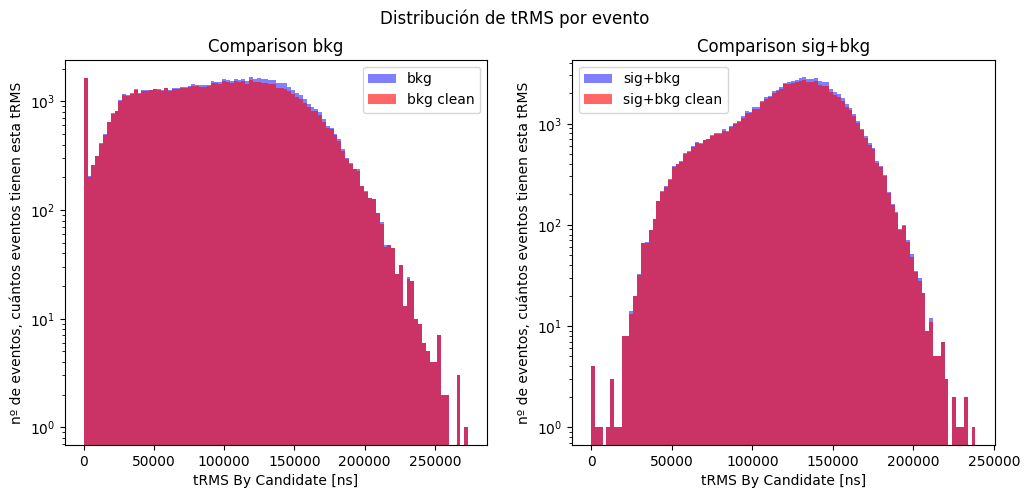

In [17]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_trms_by_event_bkg, 100, histtype="stepfilled", alpha=0.5, label="bkg", color="b")
plt.hist(total_trms_by_event_bkg_clean, 100, histtype="stepfilled", alpha=0.6, label="bkg clean", color="r")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Comparison bkg")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_trms_by_event_sig, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg", color="b")
plt.hist(total_trms_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.6, label="sig+bkg clean", color="r")
#plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, label="sig")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Comparison sig+bkg")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de tRMS por evento")



La tRMS es la desviación estándar de los tiempos de llegada de los hits en un evento. Si los hits que forman un evento llegaran a la vez, el tRMS sería cero, i.e., cuanto más dispersos en el tiempo, mayor será la tRMS. Vemos que el pico corresponde a que hay muchos eventos con tRMS pequeña (los hits llegan casi a la vez). Que haya esta diferencia tan marcada entre bkg y sig+bkg sugiere que el detector tiene buena resolución para identificar candidates deseados basándose en el tiempo.

Si quiero hacer un corte para quedarme solo con los eventos más probables de ser reales lo haría en tRMS < 2 [ns]: conservo gran parte de sig (pico) y elimino gran parte del bkg.

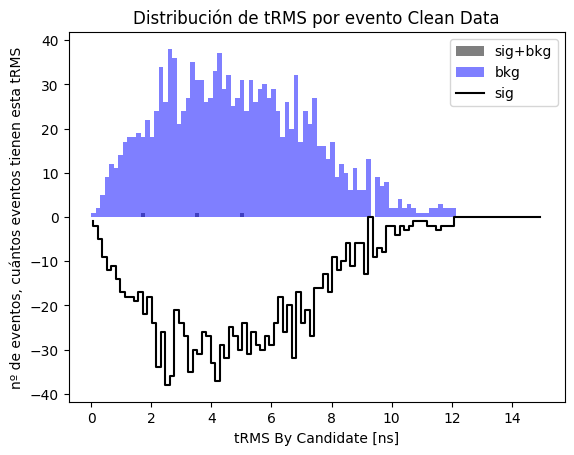

In [18]:
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_event_sig_clean, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_event_bkg_clean, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???
#Este código separa los dos arrays de hist (así después me evito tener que usar weights y es solo hacer una resta)


#total_trms_by_event_pure_sig = total_trms_by_event_sig_clean - total_trms_by_event_bkg_clean  Esto no funciona porque son series de longitudes diferentes, mmm no?

weights_sig_trms = np.ones_like(total_trms_by_event_sig_clean)
weights_bkg_trms_4 = -  1*np.ones_like(total_trms_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_trms = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])   #lo junto todo
all_weights_trms_4 = np.concatenate([weights_sig_trms, weights_bkg_trms_4])

#plt.hist(all_trms, 100, weights=all_weights_trms_4, histtype="step", alpha=1, label="sig4, not correct", color="r")

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()

#plt.yscale("log")

# RECAP DE LOS PLOTS CON CLEAN DATA

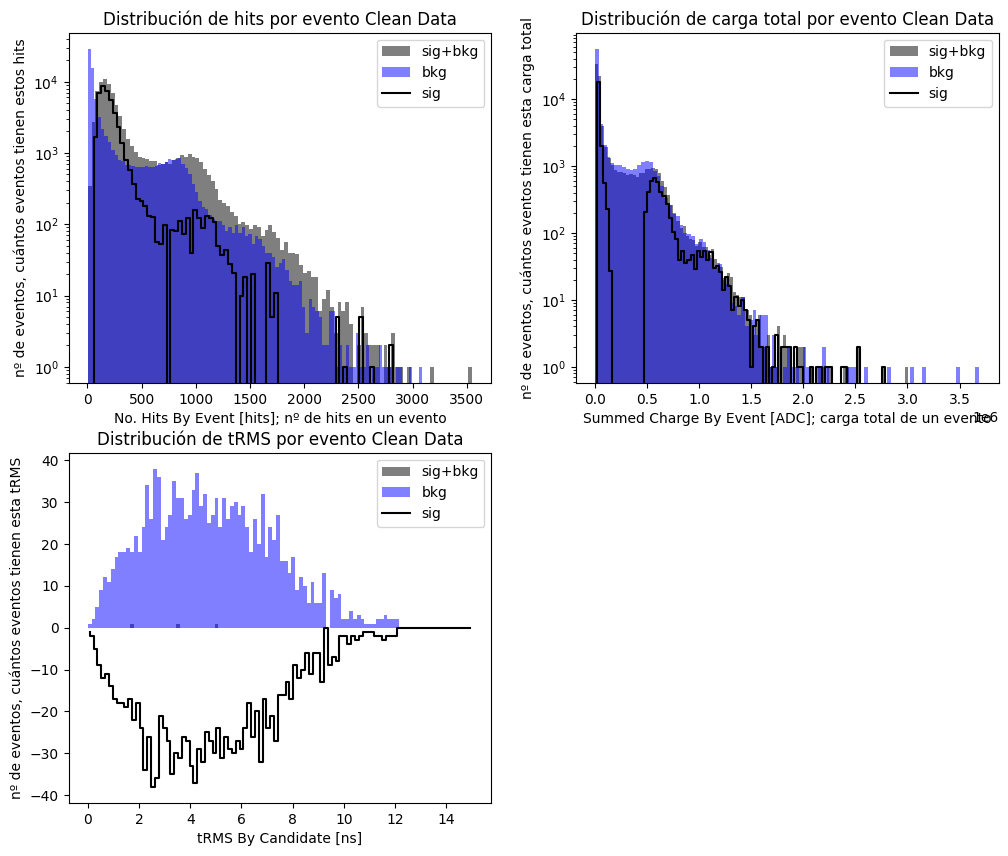

In [19]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, label="sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(2)

counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_charge = (edges_sig_charge[:-1] + edges_sig_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, label="sig", color="k") ;

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()
#plt.xlim(0,70000)

subplot(3)
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_event_sig_clean, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_event_bkg_clean, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???
#Este código separa los dos arrays de hist (así después me evito tener que usar weights y es solo hacer una resta)

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")

# CORTES CON MASKS

## Cortes en nhits por evento

In [20]:
#hago los cortes: busco los eventos con número de hits entre 5(10) y 60 hits.
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_5_bkg = (total_nhits_by_event_bkg_clean > 5) & (total_nhits_by_event_bkg_clean <= 60)
mask_5_sig = (total_nhits_by_event_sig_clean > 5) & (total_nhits_by_event_sig_clean <= 60)  #no puedo usar la misma máscara para los dos porq son series diferentes

mask_10_bkg = (total_nhits_by_event_bkg_clean > 10) & (total_nhits_by_event_bkg_clean <= 60)
mask_10_sig = (total_nhits_by_event_sig_clean > 10) & (total_nhits_by_event_sig_clean <= 60)


total_nhits_by_event_sig_clean_mask_5 = total_nhits_by_event_sig_clean[mask_5_sig]
total_nhits_by_event_bkg_clean_mask_5 = total_nhits_by_event_bkg_clean[mask_5_bkg]

total_nhits_by_event_sig_clean_mask_10 = total_nhits_by_event_sig_clean[mask_10_sig]
total_nhits_by_event_bkg_clean_mask_10 = total_nhits_by_event_bkg_clean[mask_10_bkg]

total_charge_by_event_sig_clean_mask_5 = total_charge_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_5.index]
total_charge_by_event_bkg_clean_mask_5 = total_charge_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_5.index]

total_charge_by_event_sig_clean_mask_10 = total_charge_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_10.index]
total_charge_by_event_bkg_clean_mask_10 = total_charge_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_10.index]

total_trms_by_event_sig_clean_mask_5 = total_trms_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_5.index]
total_trms_by_event_bkg_clean_mask_5 = total_trms_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_5.index]

total_trms_by_event_sig_clean_mask_10 = total_trms_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_10.index]
total_trms_by_event_bkg_clean_mask_10 = total_trms_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_10.index]

Text(0.5, 0.92, 'Cuts con masks para nhits')

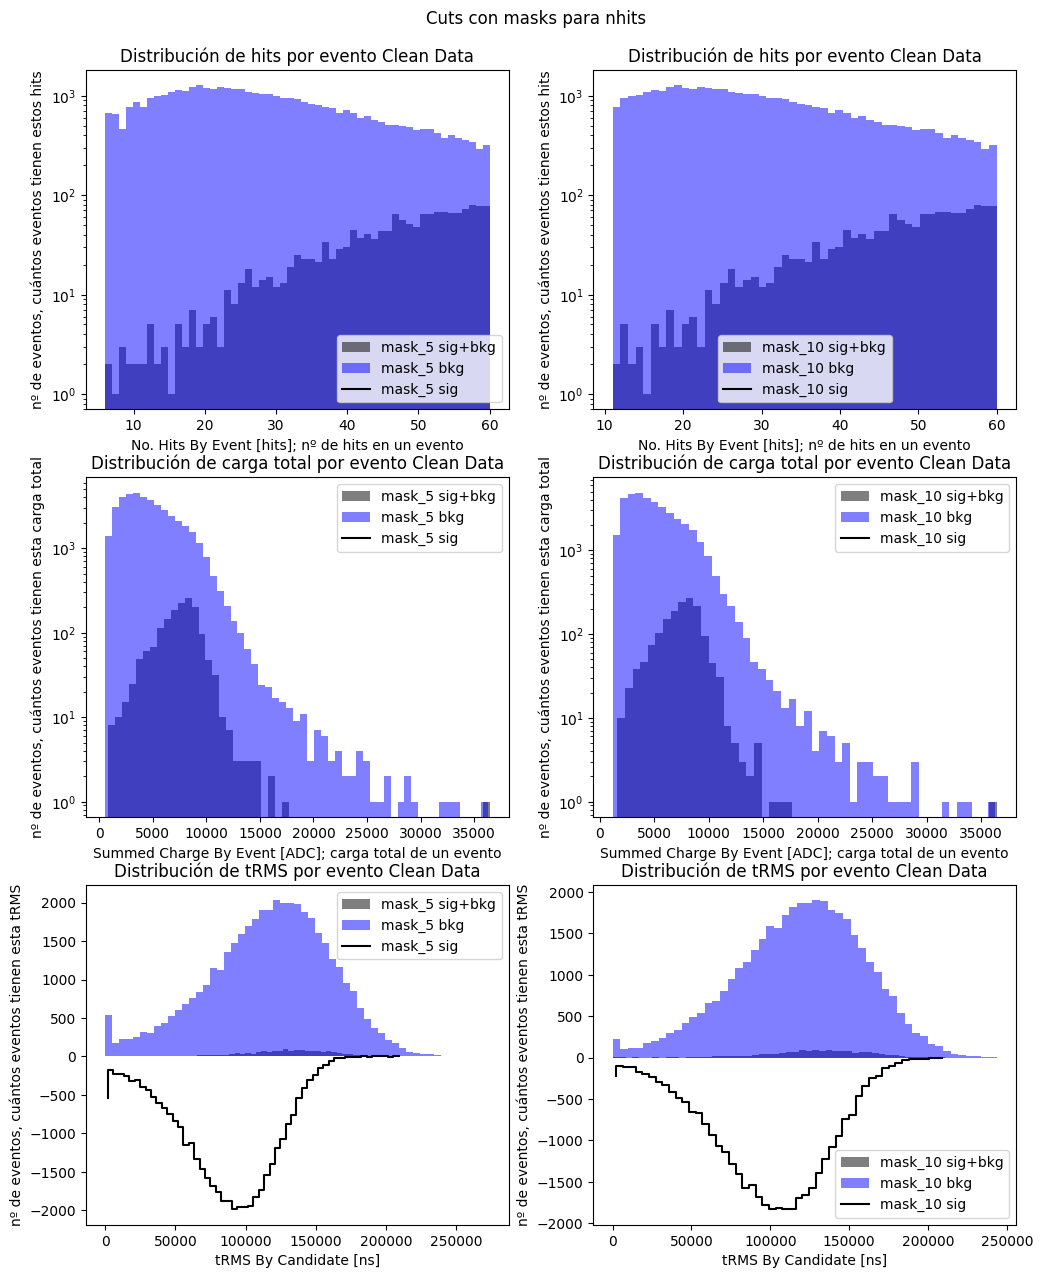

In [21]:
subplot = pltext.canvas(6)

subplot(1)
counts_sig_nhits_mask_5, edges_sig_nhits_mask_5, _ = plt.hist(total_nhits_by_event_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_5, edges_bkg_nhits_mask_5, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_nhits_mask_5 = (edges_sig_nhits_mask_5[:-1] + edges_sig_nhits_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_5, counts_sig_nhits_mask_5 - counts_bkg_nhits_mask_5, label="mask_5 sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(2)
counts_sig_nhits_mask_10, edges_sig_nhits_mask_10, _ = plt.hist(total_nhits_by_event_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_10, edges_bkg_nhits_mask_10, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_nhits_mask_10 = (edges_sig_nhits_mask_10[:-1] + edges_sig_nhits_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_10, counts_sig_nhits_mask_10 - counts_bkg_nhits_mask_10, label="mask_10 sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(3)
counts_sig_charge_mask_5, edges_sig_charge_mask_5, _ = plt.hist(total_charge_by_event_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_5, edges_bkg_charge_mask_5, _ = plt.hist(total_charge_by_event_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_charge_mask_5 = (edges_sig_charge_mask_5[:-1] + edges_sig_charge_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_5, counts_sig_charge_mask_5 - counts_bkg_charge_mask_5, label="mask_5 sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(4)
counts_sig_charge_mask_10, edges_sig_charge_mask_10, _ = plt.hist(total_charge_by_event_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 bins según nhits
counts_bkg_charge_mask_10, edges_bkg_charge_mask_10, _ = plt.hist(total_charge_by_event_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_charge_mask_10 = (edges_sig_charge_mask_10[:-1] + edges_sig_charge_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_10, counts_sig_charge_mask_10 - counts_bkg_charge_mask_10, label="mask_10 sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(5)#para trms
counts_sig_trms_mask_5, edges_sig_trms_mask_5, _ = plt.hist(total_trms_by_event_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_5, edges_bkg_trms_mask_5, _ = plt.hist(total_trms_by_event_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_trms_mask_5 = (edges_sig_trms_mask_5[:-1] + edges_sig_trms_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_5, counts_sig_trms_mask_5 - counts_bkg_trms_mask_5, label="mask_5 sig", color="k") 

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")

subplot(6)
counts_sig_trms_mask_10, edges_sig_trms_mask_10, _ = plt.hist(total_trms_by_event_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 bins según nhits
counts_bkg_trms_mask_10, edges_bkg_trms_mask_10, _ = plt.hist(total_trms_by_event_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_trms_mask_10 = (edges_sig_trms_mask_10[:-1] + edges_sig_trms_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_10, counts_sig_trms_mask_10 - counts_bkg_trms_mask_10, label="mask_10 sig", color="k") 
plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")

plt.suptitle("Cuts con masks para nhits", y=0.92)


## Corte en carga total por evento

In [22]:
#hago los cortes: busco los eventos con carga entre 0 y 100000 [ADC]. Creo que es mejor establecer 70000
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_charge_bkg = (total_charge_by_event_bkg_clean > 0) & (total_charge_by_event_bkg_clean <= 70000)
mask_charge_sig = (total_charge_by_event_sig_clean > 0) & (total_charge_by_event_sig_clean <= 70000)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_charge_by_event_sig_clean_mask_charge = total_charge_by_event_sig_clean[mask_charge_sig]
total_charge_by_event_bkg_clean_mask_charge = total_charge_by_event_bkg_clean[mask_charge_bkg]

total_nhits_by_event_sig_clean_mask_charge = total_nhits_by_event_sig_clean.loc[total_charge_by_event_sig_clean_mask_charge.index]
total_nhits_by_event_bkg_clean_mask_charge = total_nhits_by_event_bkg_clean.loc[total_charge_by_event_bkg_clean_mask_charge.index]

total_trms_by_event_sig_clean_mask_charge = total_trms_by_event_sig_clean.loc[total_charge_by_event_sig_clean_mask_charge.index]
total_trms_by_event_bkg_clean_mask_charge = total_trms_by_event_bkg_clean.loc[total_charge_by_event_bkg_clean_mask_charge.index]

Text(0.5, 0.96, 'Cuts con masks para charge')

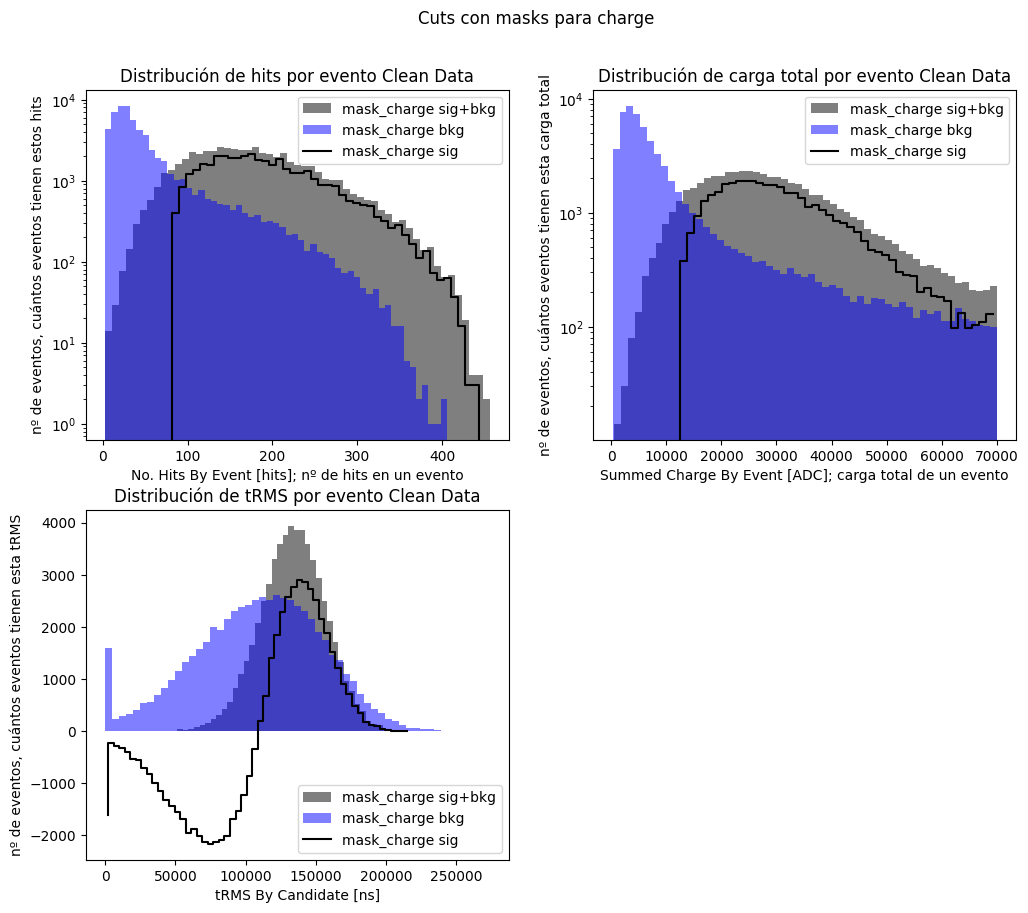

In [23]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_charge, edges_sig_nhits_mask_charge, _ = plt.hist(total_nhits_by_event_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_charge, edges_bkg_nhits_mask_charge, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_nhits_mask_charge = (edges_sig_nhits_mask_charge[:-1] + edges_sig_nhits_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_charge, counts_sig_nhits_mask_charge - counts_bkg_nhits_mask_charge, label="mask_charge sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_charge, edges_sig_charge_mask_charge, _ = plt.hist(total_charge_by_event_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_charge, edges_bkg_charge_mask_charge, _ = plt.hist(total_charge_by_event_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_charge_mask_charge = (edges_sig_charge_mask_charge[:-1] + edges_sig_charge_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_charge, counts_sig_charge_mask_charge - counts_bkg_charge_mask_charge, label="mask_charge sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()
#plt.xlim(0,100000)


subplot(3)#para trms
counts_sig_trms_mask_charge, edges_sig_trms_mask_charge, _ = plt.hist(total_trms_by_event_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_charge, edges_bkg_trms_mask_charge, _ = plt.hist(total_trms_by_event_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_trms_mask_charge = (edges_sig_trms_mask_charge[:-1] + edges_sig_trms_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_charge, counts_sig_trms_mask_charge - counts_bkg_trms_mask_charge, label="mask_charge sig", color="k") 

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con masks para charge", y=0.96)


## Corte en tRMS

In [24]:
#hago los cortes: busco los eventos con carga entre 0 y 6 [ns].
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_trms_bkg = (total_trms_by_event_bkg_clean > 0) & (total_trms_by_event_bkg_clean <= 6)
mask_trms_sig = (total_trms_by_event_sig_clean > 0) & (total_trms_by_event_sig_clean <= 6)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_trms_by_event_sig_clean_mask_trms = total_trms_by_event_sig_clean[mask_trms_sig]
total_trms_by_event_bkg_clean_mask_trms = total_trms_by_event_bkg_clean[mask_trms_bkg]

total_nhits_by_event_sig_clean_mask_trms = total_nhits_by_event_sig_clean.loc[total_trms_by_event_sig_clean_mask_trms.index]
total_nhits_by_event_bkg_clean_mask_trms = total_nhits_by_event_bkg_clean.loc[total_trms_by_event_bkg_clean_mask_trms.index]

total_charge_by_event_sig_clean_mask_trms = total_charge_by_event_sig_clean.loc[total_trms_by_event_sig_clean_mask_trms.index]
total_charge_by_event_bkg_clean_mask_trms = total_charge_by_event_bkg_clean.loc[total_trms_by_event_bkg_clean_mask_trms.index]

Text(0.5, 0.96, 'Cuts con masks para tRMS')

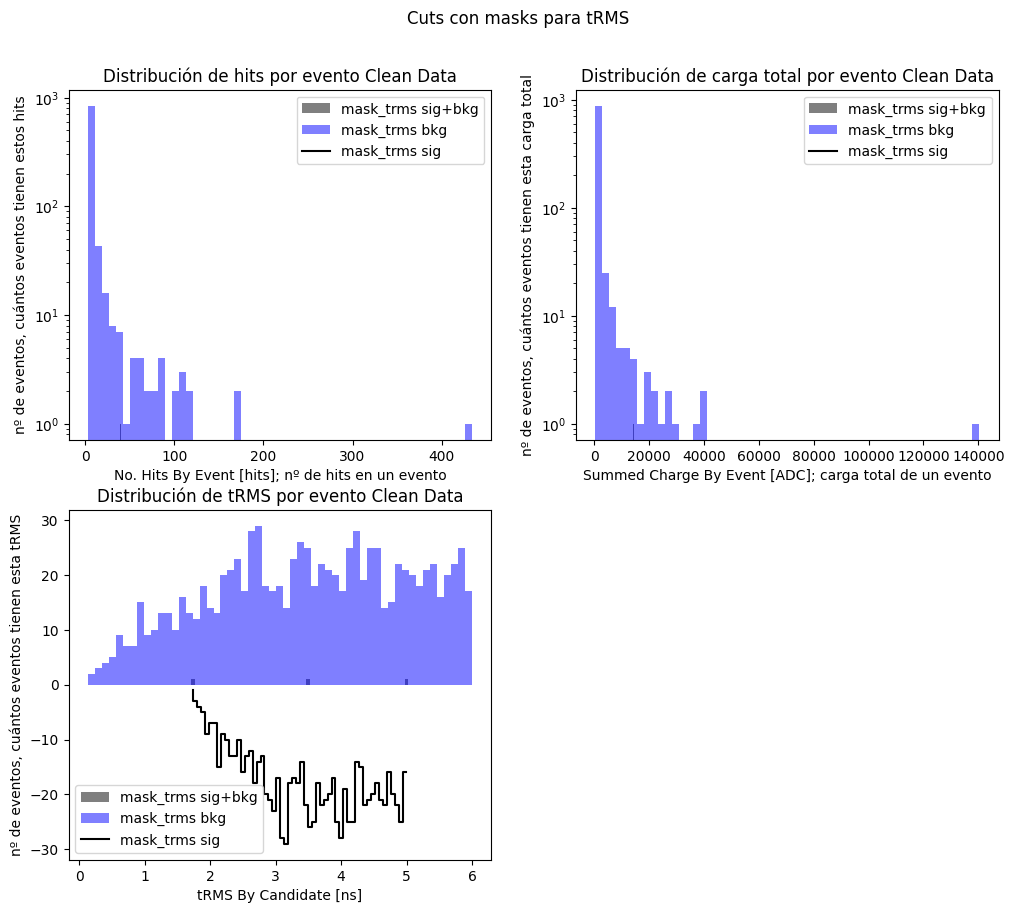

In [25]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_trms, edges_sig_nhits_mask_trms, _ = plt.hist(total_nhits_by_event_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_trms, edges_bkg_nhits_mask_trms, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_nhits_mask_trms = (edges_sig_nhits_mask_trms[:-1] + edges_sig_nhits_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_trms, counts_sig_nhits_mask_trms - counts_bkg_nhits_mask_trms, label="mask_trms sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_trms, edges_sig_charge_mask_trms, _ = plt.hist(total_charge_by_event_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_trms, edges_bkg_charge_mask_trms, _ = plt.hist(total_charge_by_event_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_charge_mask_trms = (edges_sig_charge_mask_trms[:-1] + edges_sig_charge_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_trms, counts_sig_charge_mask_trms - counts_bkg_charge_mask_trms, label="mask_trms sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(3)#para trms
counts_sig_trms_mask_trms, edges_sig_trms_mask_trms, _ = plt.hist(total_trms_by_event_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_trms, edges_bkg_trms_mask_trms, _ = plt.hist(total_trms_by_event_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_trms_mask_trms = (edges_sig_trms_mask_trms[:-1] + edges_sig_trms_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_trms, counts_sig_trms_mask_trms - counts_bkg_trms_mask_trms, label="mask_trms sig", color="k") 

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con masks para tRMS", y=0.96)


# Corrección a los tiempos calibrados en cada evento

*Trigger*: es el mecanismo q decide cuándo guardar datos (porq al detector le llegan tantos que no se puede guardar todo). En nuestro experimento el trigger es código, pero podría ser también hardware

*Readout window*: intervalo de $t$ en el q el WCTE guarda los hits después del trigger. Diego la definió como 20 [ns]. Entonces, un evento es el conjunto de hits registrados en una readout window, mientra que un candidato es una posible señal física detectada dentro de un evento.

*Dead time*: intervalo de $t$ desupués de registrar una señal en el que el WCTE no puede registrar otra. Diego la definió como 20 [ns]. Al coincidir dead time = readout window, evitamos que los eventos estén solapados, i.e., dos eventos distintos dentro de la misma readout window serían difíciles de separar

In [26]:
#quiero insertar una nueva columna en data_bkg y data_sig. En esta columna irán los tiempos en los que llega el hit respecto del primero de SU evento
#Tendré que hacer una resta del hit_pmt_calibrated_times de los hits respecto del primero, para cada hit en cada evento

hit_pmt_calibrated_times_by_event_bkg = data_by_event_bkg["hit_pmt_calibrated_times"]
hit_pmt_calibrated_times_by_event_sig = data_by_event_sig["hit_pmt_calibrated_times"]

def correct_times(times):
    t0 = times.iloc[0]  #primer hit del evento como ref
    return times - t0

corrected_times_bkg = hit_pmt_calibrated_times_by_event_bkg.apply(correct_times).reset_index(level=0, drop=True)
corrected_times_sig = hit_pmt_calibrated_times_by_event_sig.apply(correct_times).reset_index(level=0, drop=True)
#tengo q usar sí o sí .reset_index(level=0, drop=True) para que corrected_times tenga el mismo índice que data_bkg data_sig, fila por fila
#level=0 elimina el índice del grupo (event_id)
#drop=True no lo convierte en columna, sólo ajusta el índice

data_bkg["pmt_hit_calibrated_times_corrected"] = corrected_times_bkg
data_sig["pmt_hit_calibrated_times_corrected"] = corrected_times_sig



In [27]:
data_bkg

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,pmt_hit_calibrated_times_corrected
0,0,0,0,209221.084343,103.0,19,12,373,0.000000
1,1,0,0,209223.152791,119.0,19,4,365,2.068448
2,2,0,0,209233.144440,175.0,19,10,371,12.060098
3,3,0,1,209588.321986,97.0,100,0,1900,367.237643
4,4,0,1,209590.743413,104.0,101,13,1932,369.659070
...,...,...,...,...,...,...,...,...,...
18253236,18253236,83110,645853,247287.565400,180.0,3,18,75,126564.920904
18253237,18253237,83110,645854,331560.611688,141.0,8,1,153,210837.967192
18253238,18253238,83110,645854,331562.449078,97.0,2,1,39,210839.804581
18253239,18253239,83110,645854,331566.346411,132.0,52,10,998,210843.701915


In [28]:
data_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,pmt_hit_calibrated_times_corrected
0,0,0,0,63479.663380,83.0,1,5,24,0.000000
1,1,0,0,63480.392541,133.0,46,12,886,0.729161
2,2,0,0,63496.106182,180.0,8,5,157,16.442802
3,3,0,1,65913.196181,75.0,69,17,1328,2433.532801
4,4,0,1,65913.202297,137.0,70,1,1331,2433.538916
...,...,...,...,...,...,...,...,...,...
30143260,30143260,83111,1955360,494925.804957,111.0,88,9,1681,471708.240225
30143261,30143261,83111,1955360,494926.207864,215.0,90,16,1726,471708.643131
30143262,30143262,83111,1955360,494926.448105,161.0,88,8,1680,471708.883373
30143263,30143263,83111,1955360,494926.550472,61.0,89,17,1708,471708.985739


Text(0.5, 0.98, 'Comparison mean_times por evento')

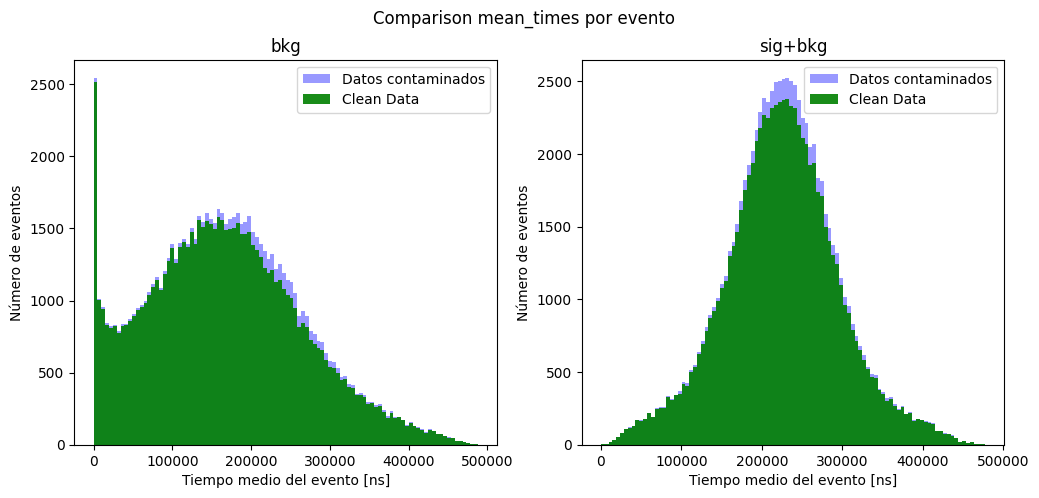

In [30]:
mean_times_by_event_bkg = data_by_event_bkg["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig = data_by_event_sig["pmt_hit_calibrated_times_corrected"].mean()


mean_times_by_event_bkg_clean = mean_times_by_event_bkg.drop(combined_series_bkg.index)
mean_times_by_event_sig_clean = mean_times_by_event_sig.drop(combined_series_sig.index)

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_event_bkg, 100, color="b", label="Datos contaminados", alpha=0.4)
#plt.hist(mean_times_by_event_bkg_only_spills, bins=100, color="green",label="Only spills", alpha=0.7)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.9)
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_event_sig, 100, color="b", label="Datos contaminados",alpha=0.4)
#plt.hist(mean_times_by_event_sig_only_spills, bins=100, color="green",label="Only spills", alpha=0.7)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.9)
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por evento")

## Aplicamos las masks

In [31]:
#hacemos lo mismo pero SÓLO para los eventos que pasan el cut de mask_5 y mask_10

events_bkg_mask_5 = total_nhits_by_event_bkg_clean[mask_5_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
events_bkg_mask_10 = total_nhits_by_event_bkg_clean[mask_10_bkg].index
events_sig_mask_5 = total_nhits_by_event_sig_clean[mask_5_sig].index
events_sig_mask_10 = total_nhits_by_event_sig_clean[mask_10_sig].index


data_bkg_mask_5 = data_bkg[data_bkg["event_id"].isin(events_bkg_mask_5)]    # .isin() devuelve una serie de valores True/False 
data_bkg_mask_10 = data_bkg[data_bkg["event_id"].isin(events_bkg_mask_10)]  #data_bkg[ lista de isin] es la serie en la que las filas es el resultado True
data_sig_mask_5 = data_sig[data_sig["event_id"].isin(events_sig_mask_5)]
data_sig_mask_10 = data_sig[data_sig["event_id"].isin(events_sig_mask_10)]

data_bkg_by_event_mask_5 = data_bkg_mask_5.groupby("event_id")  #agrupo de nuevo los hits en sus eventos
data_bkg_by_event_mask_10 = data_bkg_mask_10.groupby("event_id")
data_sig_by_event_mask_5 = data_sig_mask_5.groupby("event_id")
data_sig_by_event_mask_10 = data_sig_mask_10.groupby("event_id")


mean_times_by_event_bkg_mask_5 = data_bkg_by_event_mask_5["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_bkg_mask_10 = data_bkg_by_event_mask_10["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig_mask_5 = data_sig_by_event_mask_5["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig_mask_10 = data_sig_by_event_mask_10["pmt_hit_calibrated_times_corrected"].mean()


Text(0.5, 0.98, 'Comparison mean_times por evento con cuts en nhits')

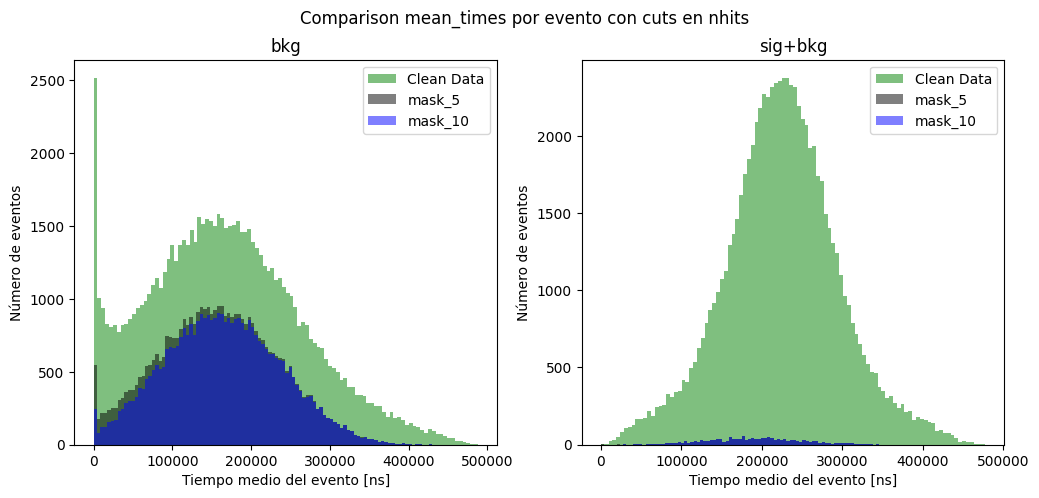

In [32]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_bkg_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_event_bkg_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_sig_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_event_sig_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por evento con cuts en nhits")

In [33]:
#hacemos lo mismo pero SÓLO para los eventos que pasan el cut de mask_charge

events_bkg_mask_charge = total_nhits_by_event_bkg_clean[mask_charge_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
events_sig_mask_charge = total_nhits_by_event_sig_clean[mask_charge_sig].index

data_bkg_mask_charge = data_bkg[data_bkg["event_id"].isin(events_bkg_mask_charge)]    # .isin() devuelve una serie de valores True/False 
data_sig_mask_charge = data_sig[data_sig["event_id"].isin(events_sig_mask_charge)]

data_bkg_by_event_mask_charge = data_bkg_mask_charge.groupby("event_id")  #agrupo de nuevo los hits en sus eventos
data_sig_by_event_mask_charge = data_sig_mask_charge.groupby("event_id")

mean_times_by_event_bkg_mask_charge = data_bkg_by_event_mask_charge["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig_mask_charge = data_sig_by_event_mask_charge["pmt_hit_calibrated_times_corrected"].mean()

Text(0.5, 0.98, 'Comparison mean_times por evento con cuts en charge')

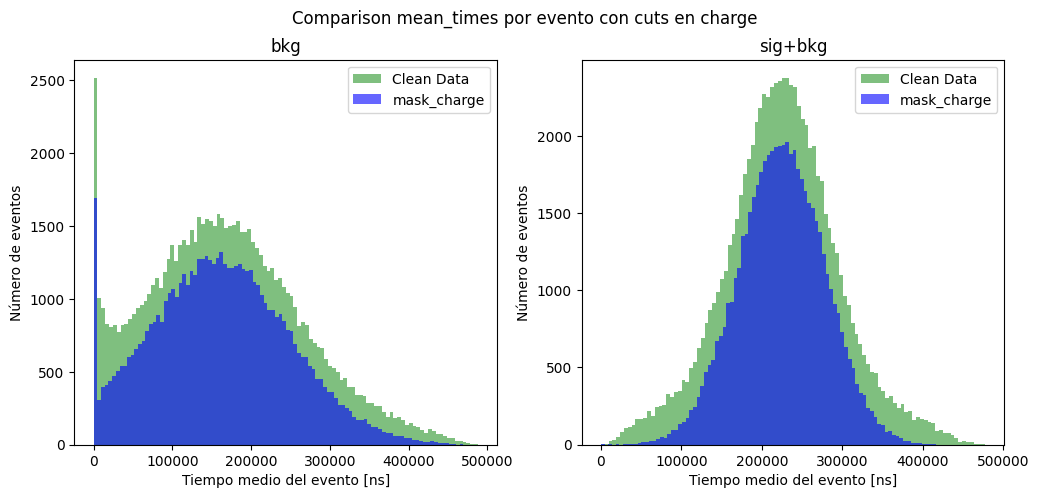

In [34]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_bkg_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_sig_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por evento con cuts en charge")

In [35]:
#hacemos lo mismo pero SÓLO para los eventos que pasan el cut de mask_trms

events_bkg_mask_trms = total_nhits_by_event_bkg_clean[mask_trms_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
events_sig_mask_trms = total_nhits_by_event_sig_clean[mask_trms_sig].index

data_bkg_mask_trms = data_bkg[data_bkg["event_id"].isin(events_bkg_mask_trms)]    # .isin() devuelve una serie de valores True/False 
data_sig_mask_trms = data_sig[data_sig["event_id"].isin(events_sig_mask_trms)]

data_bkg_by_event_mask_trms = data_bkg_mask_trms.groupby("event_id")  #agrupo de nuevo los hits en sus eventos
data_sig_by_event_mask_trms = data_sig_mask_trms.groupby("event_id")

mean_times_by_event_bkg_mask_trms = data_bkg_by_event_mask_trms["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig_mask_trms = data_sig_by_event_mask_trms["pmt_hit_calibrated_times_corrected"].mean()

Text(0.5, 0.98, 'Comparison mean_times por evento con cuts en tRMS')

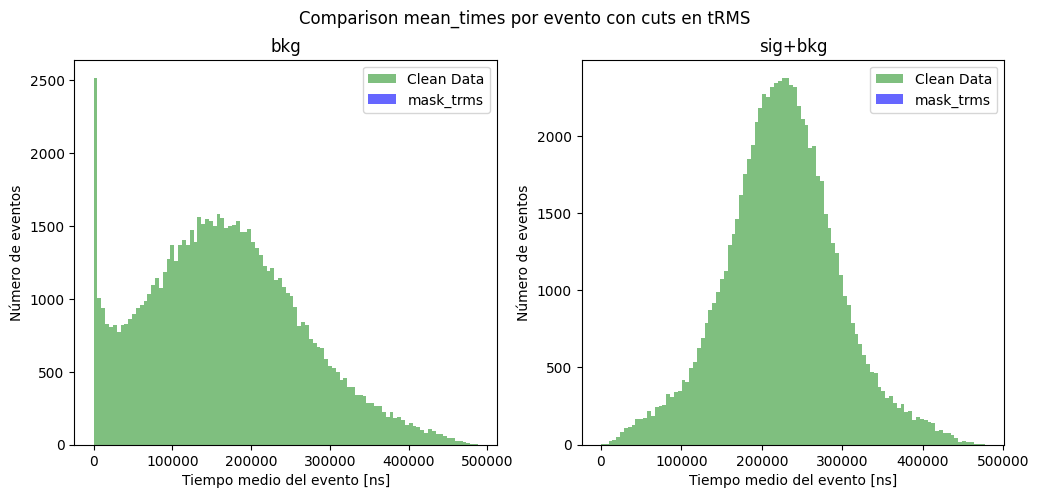

In [36]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_bkg_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_sig_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por evento con cuts en tRMS")

## Recap distrib no. eventos y tiempo medio con masks

Text(0.5, 1.0, 'sig+bkg')

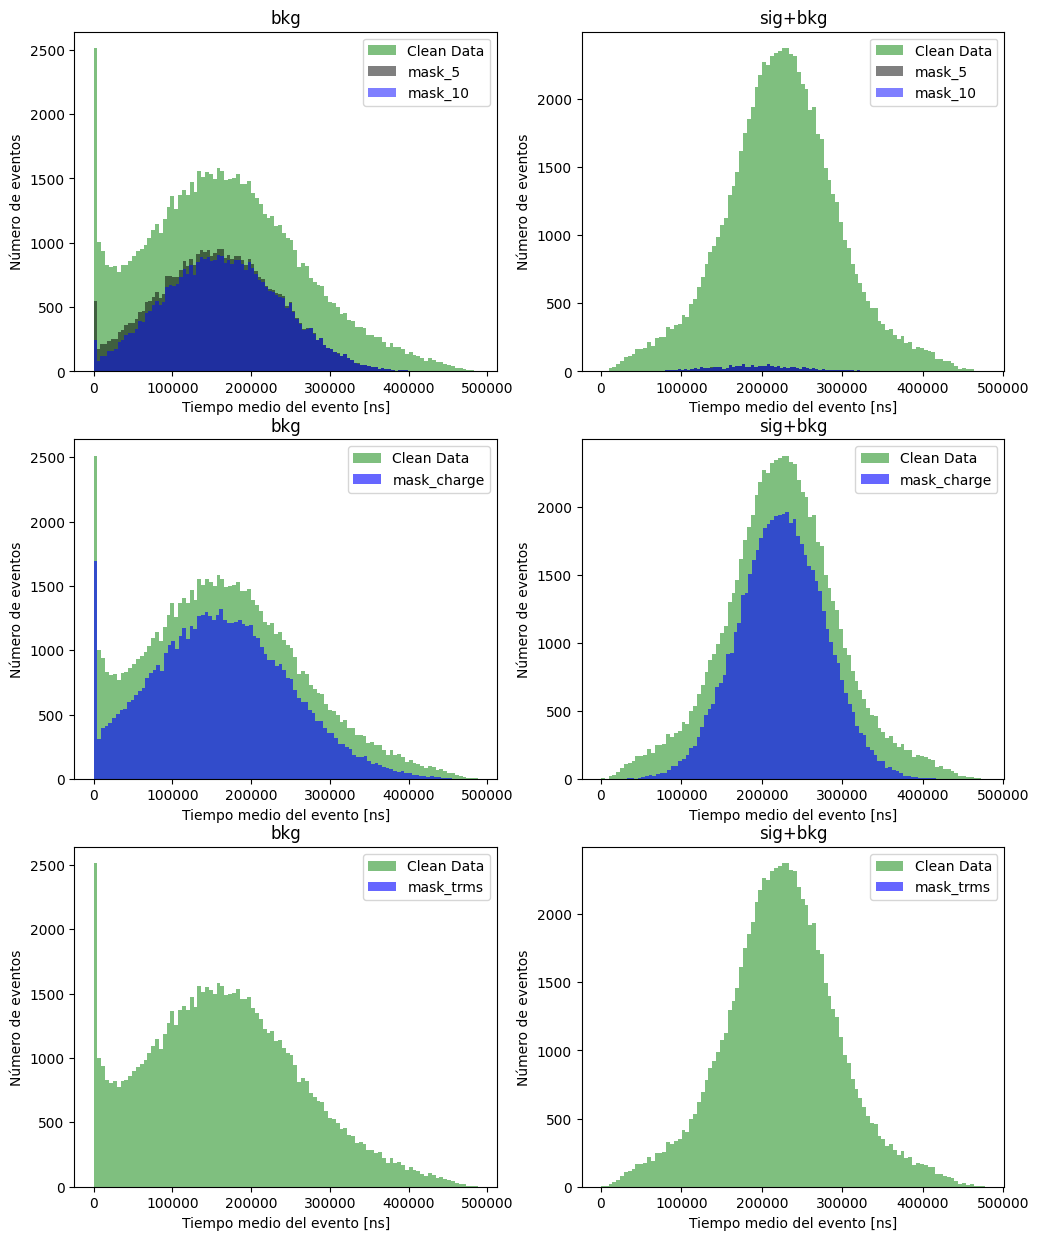

In [37]:
subplot = pltext.canvas(6)

subplot(1)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_bkg_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_event_bkg_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_sig_mask_5, bins=100, alpha=0.5, label="mask_5")
plt.hist(mean_times_by_event_sig_mask_10, bins=100, alpha=0.5, label="mask_10")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")

subplot(3)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_bkg_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(4)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_sig_mask_charge, bins=100, alpha=0.6, label="mask_charge", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")

subplot(5)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_bkg_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(6)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="g",label="Clean Data", alpha=0.5)
plt.hist(mean_times_by_event_sig_mask_trms, bins=100, alpha=0.6, label="mask_trms", color="b")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")